In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sequence.kernel.timeline import Timeline
from sequence.topology.optical_nodes import PolarizationAnalyzerNode
from sequence.topology.optical_nodes import SpdcSourceNode
from sequence.components.fiber_quantum_channel import fiberQuantumChannel, FiberSpec, FiberSection
from sequence.constants import SPEED_OF_LIGHT
from helpers import sliding_windows_coincidences

plt.rcParams.update({
    'font.size':20,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20
})

# ========================================
# HELPER FUNCTION: Robust FWHM Calculation
# ========================================

def calculate_fwhm_robust(bin_centers, histogram):
    """
    Robust FWHM calculation with better error handling.
    
    Args:
        bin_centers: Center positions of histogram bins
        histogram: Histogram counts
        
    Returns:
        FWHM in same units as bin_centers, or 0 if no peak found
    """
    if len(histogram) == 0 or np.max(histogram) <= 0:
        return 0.0
    
    # Find peak
    peak_idx = np.argmax(histogram)
    peak_val = histogram[peak_idx]
    half_max = peak_val / 2.0
    
    # Find left half-max crossing
    left_idx = peak_idx
    while left_idx > 0 and histogram[left_idx] >= half_max:
        left_idx -= 1
    
    # Interpolate for better accuracy
    if left_idx < len(histogram) - 1 and histogram[left_idx] < half_max < histogram[left_idx + 1]:
        frac = (half_max - histogram[left_idx]) / (histogram[left_idx + 1] - histogram[left_idx])
        left_pos = bin_centers[left_idx] + frac * (bin_centers[left_idx + 1] - bin_centers[left_idx])
    else:
        left_pos = bin_centers[left_idx]
    
    # Find right half-max crossing
    right_idx = peak_idx
    while right_idx < len(histogram) - 1 and histogram[right_idx] >= half_max:
        right_idx += 1
    
    # Interpolate
    if right_idx > 0 and histogram[right_idx] < half_max < histogram[right_idx - 1]:
        frac = (half_max - histogram[right_idx]) / (histogram[right_idx - 1] - histogram[right_idx])
        right_pos = bin_centers[right_idx] + frac * (bin_centers[right_idx - 1] - bin_centers[right_idx])
    else:
        right_pos = bin_centers[right_idx]
    
    fwhm = abs(right_pos - left_pos)
    
    # Sanity check: FWHM should be at least 2 bins wide
    bin_width = abs(bin_centers[1] - bin_centers[0]) if len(bin_centers) > 1 else 1
    if fwhm < 2 * bin_width:
        # Peak is too narrow, might be a single spike
        return 2 * bin_width  # Return minimum reasonable width
    
    return fwhm

def simple_coincidence_histogram(timestamps_A, timestamps_B, 
                                 time_range_ns=10, bin_width_ps=50):
    """
    Simple coincidence histogram calculation.
    
    For each photon in channel A, find all photons in channel B within 
    the time window and compute time differences.
    
    Args:
        timestamps_A: Array of detection times in ps (e.g., signal channel)
        timestamps_B: Array of detection times in ps (e.g., idler channel)
        time_range_ns: Total histogram range in ns (±range/2)
        bin_width_ps: Histogram bin width in ps
        
    Returns:
        dict with histogram data and statistics
    """
    timestamps_A = np.array(timestamps_A, dtype=float)
    timestamps_B = np.array(timestamps_B, dtype=float)
    
    # Convert range to ps
    half_range_ps = (time_range_ns * 1000) / 2.0
    
    # Collect all time differences
    time_diffs = []
    
    # For each photon in channel A
    for tA in timestamps_A:
        # Find all B photons within window
        mask = np.abs(timestamps_B - tA) <= half_range_ps
        tB_candidates = timestamps_B[mask]
        
        # Calculate time differences (tA - tB)
        for tB in tB_candidates:
            time_diffs.append(tA - tB) 
    
    time_diffs = np.array(time_diffs)
    
    if len(time_diffs) == 0:
        # No coincidences found
        n_bins = int((2 * half_range_ps) / bin_width_ps)
        return {
            'histo_vals': np.zeros(n_bins),
            'bin_edges': np.linspace(-half_range_ps, half_range_ps, n_bins + 1),
            'time_diffs': time_diffs,
            'coincidence_count': 0,
            'rate_A_Hz': 0,
            'rate_B_Hz': 0,
        }
    
    # Create histogram
    n_bins = int((2 * half_range_ps) / bin_width_ps)
    histo_vals, bin_edges = np.histogram(
        time_diffs, 
        bins=n_bins, 
        range=(-half_range_ps, half_range_ps)
    )
    
    return {
        'histo_vals': histo_vals,
        'bin_edges': bin_edges,
        'time_diffs': time_diffs,
        'coincidence_count': len(time_diffs),
        'rate_A_Hz': len(timestamps_A),
        'rate_B_Hz': len(timestamps_B),
    }

# ========================================
# CD VALIDATION: Peak Broadening
# ========================================

def plot_coincidence_histograms_cd():
    """
    Plot coincidence histograms at multiple distances to visualize CD effect.
    Top row: Coincidence histograms for all distances
    Bottom row: CD delay distributions for all distances
    """
    distances_km = [1, 10, 25, 50]
    
    print("\nGenerating CD coincidence histograms...")
    
    emission_time = 1.0
    frequency = 1e6
    
    # Create figure with 2 ROWS × 4 COLUMNS
    fig = plt.figure(figsize=(25, 10))
    gs = fig.add_gridspec(2, 4, hspace=0.35, wspace=0.3)
    
    for idx, dist_km in enumerate(distances_km):
        dist_m = dist_km * 1000
        
        # Adaptive bin width based on distance
        if dist_km <= 1:
            bin_width_ps = 20
        elif dist_km <= 10:
            bin_width_ps = 50
        elif dist_km <= 25:
            bin_width_ps = 100
        else:
            bin_width_ps = 200
        
        end_time = emission_time * 1e12 + round(max(dist_m, 1) / SPEED_OF_LIGHT) + 1e6
        tl = Timeline(stop_time=end_time)
        num_pulses = int(frequency * emission_time)
        
        source = SpdcSourceNode("source", tl, config={
            "wavelengths": [1549.5, 1550.5], 
            "bandwidth": 1.0,
            "frequency": frequency,
            "mean_photon_num": 0.01,
            "bell_state": "psi-",
        })
        
        analyzer_A = PolarizationAnalyzerNode("analyzer_A", tl, config={
            "mode": "hwp_only", 
            "detector_efficiency": 1.0, 
            "dark_count": 0,
            "mismeasure_prob": 0.0
        })
        analyzer_B = PolarizationAnalyzerNode("analyzer_B", tl, config={
            "mode": "hwp_only", 
            "detector_efficiency": 1.0, 
            "dark_count": 0,
            "mismeasure_prob": 0.0,
        })
        
        analyzer_A.set_rotation_angle(0)
        analyzer_B.set_rotation_angle(0)
        
        spec = FiberSpec(
            temperature_C=25,
            core_ellipticity=1.0,
            bend_radius_m=0.0,
            twist_rate_rad_per_m=0.0
        )
        
        qc_A = fiberQuantumChannel("qc_A", tl, distance=dist_m, 
                                    attenuation=0.0002,
                                    sections=[FiberSection(dist_m, spec)])
        qc_B = fiberQuantumChannel("qc_B", tl, distance=dist_m, 
                                    attenuation=0.0002,
                                    sections=[FiberSection(dist_m, spec)])
        
        qc_A.enable_delay_tracking()
        qc_B.enable_delay_tracking()
        
        qc_A.set_ends(source, analyzer_A.name)
        qc_B.set_ends(source, analyzer_B.name)
        
        tl.init()
        source.spdc.emit(num_pulses=num_pulses)
        tl.run()
        
        print(f"Distance {dist_km} km: emitted {source.emission_count} pairs")
        
        # Get timestamps
        tags_A_H = analyzer_A.get_photon_times()[0]
        tags_B_V = analyzer_B.get_photon_times()[1]
       
        coinc_result = simple_coincidence_histogram(
            tags_A_H, tags_B_V, 
            time_range_ns=6, 
            bin_width_ps=bin_width_ps
        )
        
        histo = coinc_result['histo_vals']
        edges = coinc_result['bin_edges']
        centers = 0.5 * (edges[:-1] + edges[1:])
        
        # Convert counts to rates (per second)
        histo_rate = histo / emission_time  # counts/s
        
        # Get CD delay statistics
        stats_A = qc_A.get_cd_delay_statistics()
        stats_B = qc_B.get_cd_delay_statistics()
        
        # Calculate FWHM and Peak position
        fwhm = calculate_fwhm_robust(centers, histo)
        peak_idx = np.argmax(histo) if len(histo) > 0 else 0
        peak_position = centers[peak_idx] if len(centers) > 0 else 0
        
        # Calculate rates
        coinc_rate = coinc_result['coincidence_count'] / emission_time
        singles_rate_A = len(tags_A_H) / emission_time
        singles_rate_B = len(tags_B_V) / emission_time
        
        # ==================== PLOT 1: COINCIDENCE HISTOGRAM (TOP ROW) ====================
        ax_coinc = fig.add_subplot(gs[0, idx])  # Row 0, column idx
        ax_coinc.bar(centers, histo_rate, width=(edges[1]-edges[0]), 
                     alpha=0.7, color='green', edgecolor='black')

        ax_coinc.axvline(x=peak_position, color='orange', linestyle='-', linewidth=2, alpha=0.7)
        
        # Info box with rates
        info_text = f'FWHM: {fwhm:.0f} ps\n'
        info_text += f'Peak: {peak_position:.0f} ps\n'
        info_text += f'Rate: {coinc_rate:.0f} /s'
        
        ax_coinc.text(0.05, 0.95, info_text, 
                     transform=ax_coinc.transAxes, fontsize=14, 
                     verticalalignment='top', fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                     family='monospace')
        
        ax_coinc.set_xlabel('Time Difference (ps)', fontweight='bold')
        ax_coinc.set_ylabel('Coincidence Rate (/s)', fontweight='bold')
        ax_coinc.set_title(f'{dist_km} km', fontweight='bold')
        ax_coinc.grid(alpha=0.3)
        if idx == 0:  # Only show legend on first plot
            ax_coinc.legend()
        
        # ==================== PLOT 2: CD DELAY DISTRIBUTION (BOTTOM ROW) ====================
        ax_cd = fig.add_subplot(gs[1, idx])  # Row 1, column idx
        
        if stats_A["count"] > 0 and stats_B["count"] > 0:
            delays_A = stats_A["delays_ps"]
            delays_B = stats_B["delays_ps"]
            
            # Convert to rates (normalize by emission time)
            ax_cd.hist(delays_A, bins=50, alpha=0.6, color='red', 
                      edgecolor='black', label='Channel A', weights=np.ones_like(delays_A) / emission_time)
            ax_cd.hist(delays_B, bins=50, alpha=0.6, color='blue', 
                      edgecolor='black', label='Channel B', weights=np.ones_like(delays_B) / emission_time)
            ax_cd.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
            
            # Calculate expected CD spread
            expected_spread = 17 * dist_km * 1.0  # D × L × bandwidth (ps)
        
        ax_cd.set_xlabel('CD Delay (ps)', fontweight='bold')
        ax_cd.set_ylabel('Rate (/s)', fontweight='bold')
        ax_cd.set_title(f'{dist_km} km: CD Distribution', fontweight='bold')
        ax_cd.grid(alpha=0.3)
        
        # Print detailed summary
        print(f"\n{'='*70}")
        print(f"Distance: {dist_km} km (bin width: {bin_width_ps} ps)")
        print(f"{'='*70}")
        print(f"Singles rates: A={singles_rate_A:.0f} /s, B={singles_rate_B:.0f} /s")
        print(f"Coincidence rate: {coinc_rate:.0f} /s")
        print(f"Coincidence FWHM: {fwhm:.1f} ps")
        print(f"CD standard deviation: A={stats_A['std_delay_ps']:.1f} ps, B={stats_B['std_delay_ps']:.1f} ps")
        print(f"Expected CD spread: {expected_spread:.1f} ps")

        print(f"{'='*70}")
    
    # Overall title
    fig.suptitle('Chromatic Dispersion Effect on Entangled Photon Distribution', 
                 fontsize=20, fontweight='bold', y=0.98)
    
    # Add row labels
    fig.text(0.02, 0.75, 'Coincidence Histograms', 
             fontsize=18, fontweight='bold', rotation=90, va='center')
    fig.text(0.02, 0.25, 'CD Delay Distributions', 
             fontsize=18, fontweight='bold', rotation=90, va='center')
    
    plt.show()



CD VALIDATION: Coincidence Histograms

Generating CD coincidence histograms...
Distance 1 km: emitted 10067 pairs

Distance: 1 km (bin width: 20 ps)
Singles rates: A=4783 /s, B=4766 /s
Coincidence rate: 4560 /s
Coincidence FWHM: 40.0 ps
CD standard deviation: A=3.7 ps, B=3.7 ps
Expected CD spread: 17.0 ps


C:\Users\ana35\AppData\Local\Temp\ipykernel_2976\3289812533.py:285: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_coinc.legend()


Distance 10 km: emitted 9910 pairs

Distance: 10 km (bin width: 50 ps)
Singles rates: A=3091 /s, B=3182 /s
Coincidence rate: 1950 /s
Coincidence FWHM: 167.6 ps
CD standard deviation: A=36.7 ps, B=36.6 ps
Expected CD spread: 170.0 ps
Distance 25 km: emitted 9933 pairs

Distance: 25 km (bin width: 100 ps)
Singles rates: A=1633 /s, B=1610 /s
Coincidence rate: 508 /s
Coincidence FWHM: 476.1 ps
CD standard deviation: A=92.0 ps, B=91.9 ps
Expected CD spread: 425.0 ps
Distance 50 km: emitted 9982 pairs

Distance: 50 km (bin width: 200 ps)
Singles rates: A=464 /s, B=518 /s
Coincidence rate: 44 /s
Coincidence FWHM: 495.0 ps
CD standard deviation: A=177.1 ps, B=181.8 ps
Expected CD spread: 850.0 ps


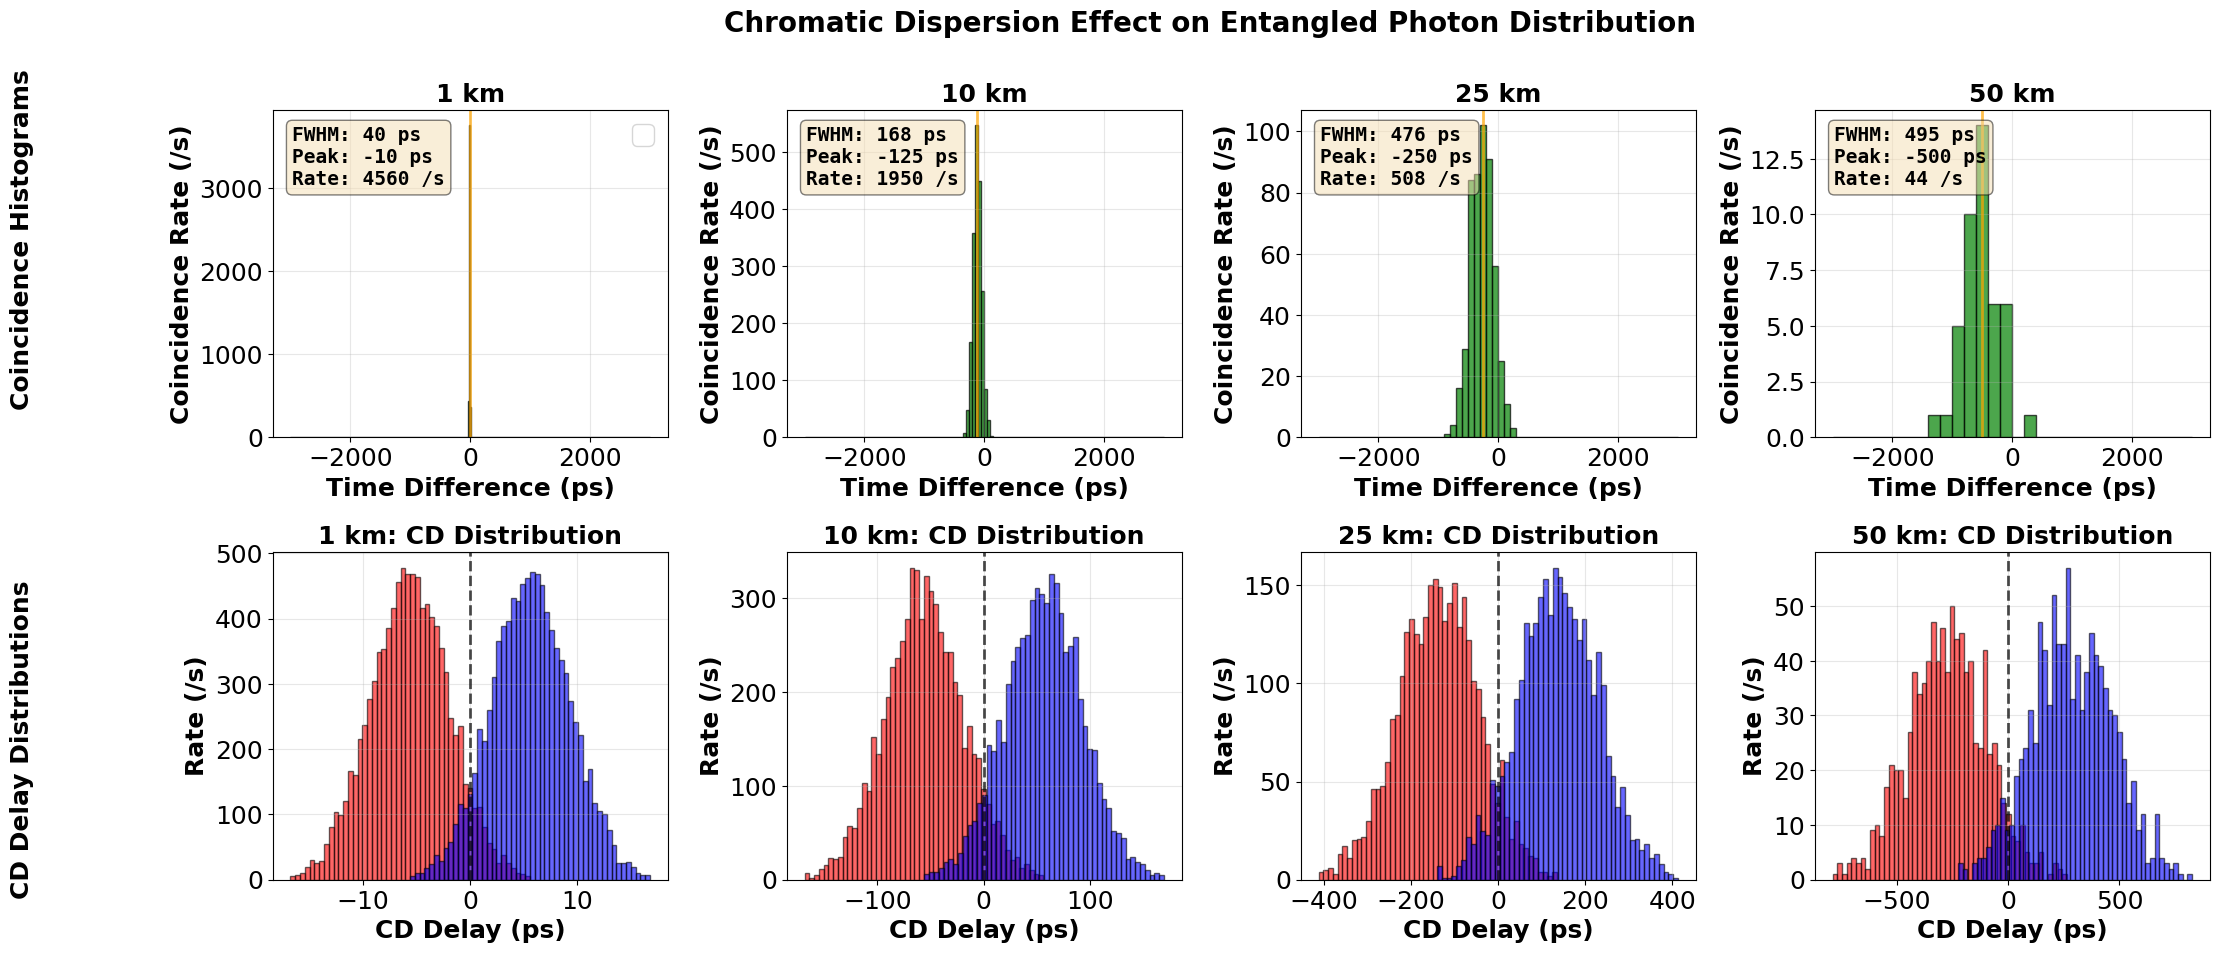

In [41]:
# CD histograms
print("\n" + "="*60)
print("CD VALIDATION: Coincidence Histograms")
print("="*60)
plot_coincidence_histograms_cd()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import radians
from multiprocess.dummy import Pool
from scipy.optimize import curve_fit

from sequence.kernel.timeline import Timeline
from sequence.topology.optical_nodes import PolarizationAnalyzerNode, SpdcSourceNode
from sequence.components.fiber_quantum_channel import fiberQuantumChannel, FiberSpec, FiberSection
from sequence.constants import SPEED_OF_LIGHT
from helpers import sliding_windows_coincidences

# Source / experiment parameters
frequency = 1e6           # Hz, pump pulse rate
mean_photon_num = 0.01    # SPDC brightness
bell_state = "psi-"       # entangled state
emmission_time = 0.2      # seconds per run

# Fiber / loss parameters
d1 = 10e3                 # Alice fiber length in meters (e.g. 10 km)
d2 = 10e3                 # Bob fiber length in meters
attenuation1 = 0.0002     # 0.2 dB/km approx → in 1/m units if that’s what your model expects
attenuation2 = 0.0002

# Reference fiber spec for Alice (no PMD)
fiber_spec_ref = FiberSpec(
    temperature_C=25.0,
    core_ellipticity=1.0,
    bend_radius_m=0.0,
    twist_rate_rad_per_m=0.0,
)

# Template for Bob; we will overwrite core_ellipticity per run
def make_fiber_spec_bob(ellipticity):
    return FiberSpec(
        temperature_C=25.0,
        core_ellipticity=ellipticity,
        bend_radius_m=0.0,
        twist_rate_rad_per_m=0.0,
    )

def cos2_model(theta_deg, A, theta0_deg, B):
    """A * cos^2(theta - theta0) + B, theta in degrees."""
    theta_rad = np.radians(theta_deg)
    theta0_rad = np.radians(theta0_deg)
    return A * (np.cos(theta_rad - theta0_rad) ** 2) + B


def compute_visibility_from_data(y):
    """Simple visibility from max/min."""
    y = np.asarray(y)
    if y.size == 0:
        return 0.0
    C_max = np.max(y)
    C_min = np.min(y)
    if C_max + C_min <= 0:
        return 0.0
    return (C_max - C_min) / (C_max + C_min)


def emit_photons(angle_rad_A, angle_rad_B, emmission_time, spec_A, spec_B):
    """
    Emit photons through two fibers and return detection times for both analyzers.
    spec_A: FiberSpec for Alice arm
    spec_B: FiberSpec for Bob arm
    """
    # Enough time so all photons arrive
    max_d = max(d1, d2)
    end_time = emmission_time * 1e12 + round(max_d / SPEED_OF_LIGHT) + 1e6  # ps

    tl = Timeline(stop_time=end_time)
    num_pulses = int(frequency * emmission_time)

    source = SpdcSourceNode("source", tl, config={
        "wavelengths": [1557.36, 1558.17],
        "bandwidth": 2.0,
        "frequency": frequency,
        "mean_photon_num": mean_photon_num,
        "bell_state": bell_state,
    })

    analyzer_A = PolarizationAnalyzerNode(
        "analyzer_A", tl,
        config={
            "mode": "hwp_only",
            "detector_efficiency": 0.85,
            "dark_count": 500,
            "mismeasure_prob": 0.005,
        },
    )
    analyzer_B = PolarizationAnalyzerNode(
        "analyzer_B", tl,
        config={
            "mode": "hwp_only",
            "detector_efficiency": 0.85,
            "dark_count": 500,
            "mismeasure_prob": 0.005,
        },
    )

    analyzer_A.set_rotation_angle(angle_rad_A)
    analyzer_B.set_rotation_angle(angle_rad_B)

    # Alice fiber: reference spec
    qc_A = fiberQuantumChannel(
        "qc_A", tl, distance=d1,
        attenuation=attenuation1,
        sections=[FiberSection(d1, spec_A)],
    )

    # Bob fiber: test spec
    qc_B = fiberQuantumChannel(
        "qc_B", tl, distance=d2,
        attenuation=attenuation2,
        sections=[FiberSection(d2, spec_B)],
    )

    qc_A.set_ends(source, analyzer_A.name)
    qc_B.set_ends(source, analyzer_B.name)

    tl.init()
    source.spdc.emit(num_pulses=num_pulses)
    tl.run()

    counts_A = analyzer_A.get_photon_times()  # [H_times, V_times]
    counts_B = analyzer_B.get_photon_times()

    return counts_A, counts_B

def analyze_windowed_coincidences(tags_A, tags_B, emmission_time=1, config= None):
    max_time_ps = emmission_time * 1e12
    time_integration_s = config.get("time_integration_ms", 1000) / 1000
    int_time_ps = time_integration_s * 1e12
    earliest_time = min(tags_A[0], tags_B[0]) if tags_A and tags_B else 0
    latest_time = earliest_time + max_time_ps

    coinc_list, CAR_list = [], []

    t = earliest_time
    while t < latest_time:
        win_A = [ts for ts in tags_A if t <= ts < t + int_time_ps]
        win_B = [ts for ts in tags_B if t <= ts < t + int_time_ps]
        result = sliding_windows_coincidences(config, np.array(win_A), np.array(win_B))
        coinc_list.append(result["coincidences_rate"])
        CAR_list.append(result["CAR"])    
        t += int_time_ps

    coinc_array = np.array(coinc_list)
    CAR_array = np.array(CAR_list)

    # --- Handle infinities ---
    if np.all(np.isinf(CAR_array)):
        CAR_mean, CAR_std = np.inf, 0.0
    else:
        # finite values only
        finite = CAR_array[np.isfinite(CAR_array)]
        if len(finite) == 0:  # all were NaN
            CAR_mean, CAR_std = np.nan, np.nan
        else:
            CAR_mean, CAR_std = finite.mean(), finite.std()

    return coinc_array.mean(), coinc_array.std(), CAR_mean, CAR_std

def test_polarization_analyzer_coincidences(
        angle_rad_A,
        angle_rad_B,
        emmission_time,
        spec_A,
        spec_B,
        config):
    """
    Run one polarization setting and return HH coincidence mean/std.
    config is passed to analyze_windowed_coincidences.
    """
    counts_A, counts_B = emit_photons(
        angle_rad_A, angle_rad_B, emmission_time,
        spec_A=spec_A, spec_B=spec_B,
    )

    # H port is index 0
    hh_mean, hh_std, _, _ = analyze_windowed_coincidences(
        counts_A[0], counts_B[0], emmission_time, config
    )
    return {"hh": (hh_mean, hh_std)}


In [ ]:
def make_fiber_spec_bob_twist(twist_rate_rad_per_m):
    return FiberSpec(
        temperature_C=25.0,
        core_ellipticity=1.0,
        bend_radius_m=0.0,
        twist_rate_rad_per_m=twist_rate_rad_per_m,
    )


def measure_visibility_for_twist(
        twist_rate_rad_per_m,
        emmission_time=0.1,
        fixed_angle_deg=0.0,
        config=None):
    """
    Same as measure_visibility_for_ellipticity, but Bob's knob is twist rate.
    """
    # Alice: reference fiber (no twist)
    spec_A = fiber_spec_ref  # ellipticity=1, twist=0

    # Bob: test fiber with given twist
    spec_B = make_fiber_spec_bob_twist(twist_rate_rad_per_m)

    # Bob angle sweep (same as before)
    angles_rad = np.radians([
        -45, -40, -35, -30, -25, -22.5, -20, -15, -10, -5,
        0, 5, 10, 15, 20, 22.5, 25, 30, 35, 40, 45,
        50, 55, 60, 65, 67.5, 70, 75, 80, 85, 90,
        95, 100, 105, 110, 112.5, 115, 120, 125, 130,
        135, 140, 145, 150, 155, 157.5, 160, 165, 170, 175, 180,
    ])
    angles_deg = np.degrees(angles_rad)

    fixed_rad = radians(fixed_angle_deg)

    jobs = [(fixed_rad, bob_angle) for bob_angle in angles_rad]

    def run_job(job_args):
        angle_A, angle_B = job_args
        stats = test_polarization_analyzer_coincidences(
            angle_rad_A=angle_A,
            angle_rad_B=angle_B,
            emmission_time=emmission_time,
            spec_A=spec_A,
            spec_B=spec_B,
            config=config,
        )
        return np.degrees(angle_B), stats

    raw = []
    with Pool() as pool:
        for bob_deg, stats in pool.imap_unordered(run_job, jobs):
            raw.append((bob_deg, stats))
            print(f"[twist={twist_rate_rad_per_m:.3f} rad/m] Bob {bob_deg:.1f}° done")

    raw_sorted = sorted(raw, key=lambda x: x[0])
    bob_degs = np.array([b for (b, _) in raw_sorted])
    hh_stats = [s["hh"] for (_, s) in raw_sorted]
    hh_means = np.array([m for (m, _) in hh_stats])
    hh_stds = np.array([s for (_, s) in hh_stats])

    # Fit cos²
    if np.all(hh_means <= 0):
        visibility = 0.0
        A_fit = theta0_fit = B_fit = 0.0
    else:
        A0 = (hh_means.max() - hh_means.min()) / 2.0
        B0 = hh_means.min()
        theta0_guess = 0.0
        p0 = [A0, theta0_guess, B0]
        try:
            popt, _ = curve_fit(cos2_model, bob_degs, hh_means, p0=p0, maxfev=10000)
            A_fit, theta0_fit, B_fit = popt
            C_max = A_fit + B_fit
            C_min = B_fit
            if C_max + C_min > 0:
                visibility = abs(C_max - C_min) / (C_max + C_min)
            else:
                visibility = 0.0
        except Exception:
            visibility = compute_visibility_from_data(hh_means)
            A_fit, theta0_fit, B_fit = 0.0, 0.0, 0.0

    data = {
        "angles_deg": bob_degs,
        "hh_means": hh_means,
        "hh_stds": hh_stds,
        "A_fit": A_fit,
        "theta0_fit": theta0_fit,
        "B_fit": B_fit,
    }
    return float(visibility), data

def plot_visibility_vs_twist():
    """
    PMD study: visibility vs twist rate.
    """
    em_time = emmission_time
    fixed_angle_deg = 0.0

    # Choose a range of twist rates (example: 0 → 0.5 rad/m)
    twist_rates = np.linspace(0.0, 0.5, 10)

    config = {
        "coincidence_window_width": 1000,
        "range_ns": 5,
        "time_bin": 0.02,
        "time_integration_ms": em_time * 1000 / 5,
        "peak0": 0,
    }

    visibilities = []
    example_fringes = {}

    print("\nMeasuring visibility vs twist rate...\n")
    for i, tr in enumerate(twist_rates):
        V, data = measure_visibility_for_twist(
            twist_rate_rad_per_m=tr,
            emmission_time=em_time,
            fixed_angle_deg=fixed_angle_deg,
            config=config,
        )
        visibilities.append(V)
        print(f"twist={tr:.3f} rad/m → visibility ≈ {V*100:.1f}%")
        example_fringes[tr] = data

    visibilities = np.array(visibilities)

    # Plot 1: visibility vs twist
    plt.figure(figsize=(7, 5))
    plt.plot(twist_rates, visibilities, 'o-', color='darkblue',
             markeredgecolor='black')
    plt.xlabel('Twist rate (rad/m)', fontweight='bold')
    plt.ylabel('Visibility', fontweight='bold')
    plt.title('Visibility vs Twist Rate', fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot 2: example fringes
    plt.figure(figsize=(8, 5))
    for tr, data in example_fringes.items():
        x = data["angles_deg"]
        y = data["hh_means"]
        yerr = data["hh_stds"]

        line = plt.errorbar(
            x, y, yerr=yerr, fmt='o', capsize=3,
            label=f'twist={tr:.2f} rad/m'
        )
        color = line[0].get_color()

        A = data["A_fit"]; theta0 = data["theta0_fit"]; B = data["B_fit"]
        if A != 0.0 or B != 0.0:
            x_fit = np.linspace(x.min(), x.max(), 500)
            y_fit = cos2_model(x_fit, A, theta0, B)
            plt.plot(x_fit, y_fit, '-', color=color, linewidth=2)

    plt.xlabel('Bob analyzer angle (deg)', fontweight='bold')
    plt.ylabel('HH coincidence rate', fontweight='bold')
    plt.title('HH fringes for selected twist rates', fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



Measuring visibility vs twist rate...

[twist=0.000 rad/m] Bob 0.0° done
[twist=0.000 rad/m] Bob -20.0° done
[twist=0.000 rad/m] Bob -22.5° done
[twist=0.000 rad/m] Bob -10.0° done
[twist=0.000 rad/m] Bob 40.0° done
[twist=0.000 rad/m] Bob 35.0° done
[twist=0.000 rad/m] Bob -45.0° done
[twist=0.000 rad/m] Bob 5.0° done
[twist=0.000 rad/m] Bob 25.0° done
[twist=0.000 rad/m] Bob -40.0° done
[twist=0.000 rad/m] Bob -35.0° done
[twist=0.000 rad/m] Bob 50.0° done
[twist=0.000 rad/m] Bob -15.0° done
[twist=0.000 rad/m] Bob -5.0° done
[twist=0.000 rad/m] Bob 10.0° done
[twist=0.000 rad/m] Bob 15.0° done
[twist=0.000 rad/m] Bob 30.0° done
[twist=0.000 rad/m] Bob 67.5° done
[twist=0.000 rad/m] Bob 65.0° done
[twist=0.000 rad/m] Bob -25.0° done
[twist=0.000 rad/m] Bob 55.0° done
[twist=0.000 rad/m] Bob 95.0° done
[twist=0.000 rad/m] Bob 70.0° done
[twist=0.000 rad/m] Bob 90.0° done
[twist=0.000 rad/m] Bob 22.5° done
[twist=0.000 rad/m] Bob 20.0° done
[twist=0.000 rad/m] Bob 125.0° done
[twist=0

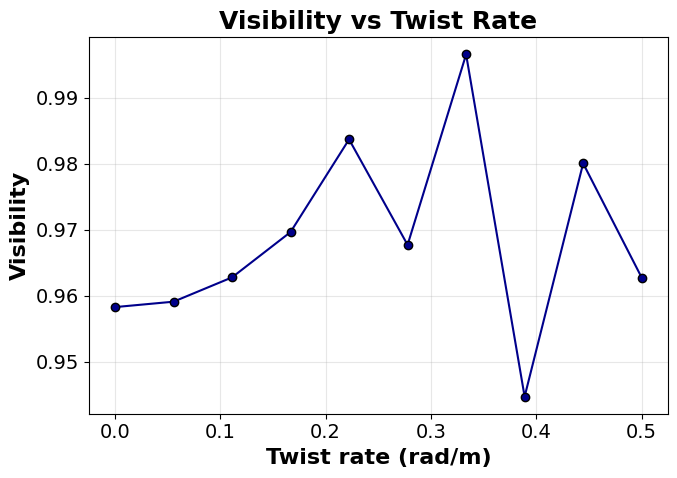

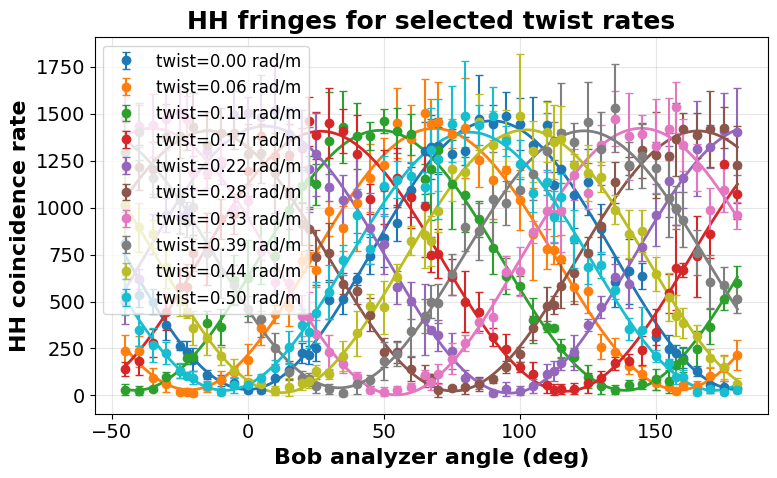

In [ ]:
plot_visibility_vs_twist()